# NMC data QC 

# Import Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import anndata as ad
import seaborn as sns
import scanpy as sc
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Inputs

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in preprocessed_dir that are not .DS_Store
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']


# Extract patients metadata and export it to the new format

In [16]:
patients_metadata = pd.read_excel(metadata_dir / 'patient_metadata.xlsx')
patients_metadata.dropna(inplace=True)
#extract from the patients_metadata "outcome" column only the digits 
patients_metadata["outcome"] = patients_metadata["outcome"].str.extract('(\d+)').astype(int)
#add a new column if the  "outcome" column is greater than 9
patients_metadata["outcome_group"] = np.where(patients_metadata["outcome"] > 6, "long_term survival", "short_term survival")
patients_metadata["rois"] = patients_metadata["rois"].astype(str)
patients_metadata['rois'] = patients_metadata['rois'].str.split(r'\+ ')
patients_metadata = patients_metadata.explode('rois', ignore_index=True)
patients_metadata['rois'] = patients_metadata['rois'].str.strip()
patients_metadata["exp_name"] = "Run" +  patients_metadata['run'].astype(int).astype(str) + '_ROI' + patients_metadata['rois'].astype(str)
conditions = [patients_metadata["site"].isin(["lung", "lung hilus right", "central left lung ", "intrathoracic, right bronchus"]), 
              patients_metadata["site"].str.contains("extrahepatic"), 
              patients_metadata["site"].str.contains("cervical"),
              patients_metadata["site"] == "sample: metastasis left tigh, skin \nprimary side: lung, main bronchus "]
outcome = ["Lung", "Bile", "Cervix", "Skin"]
patients_metadata["tissue"] = np.select(conditions, outcome, default="Other")
patients_metadata.to_csv(metadata_dir / 'new_patients_metadata.csv', index=False)

## Compare number of ROIS based on the survival time

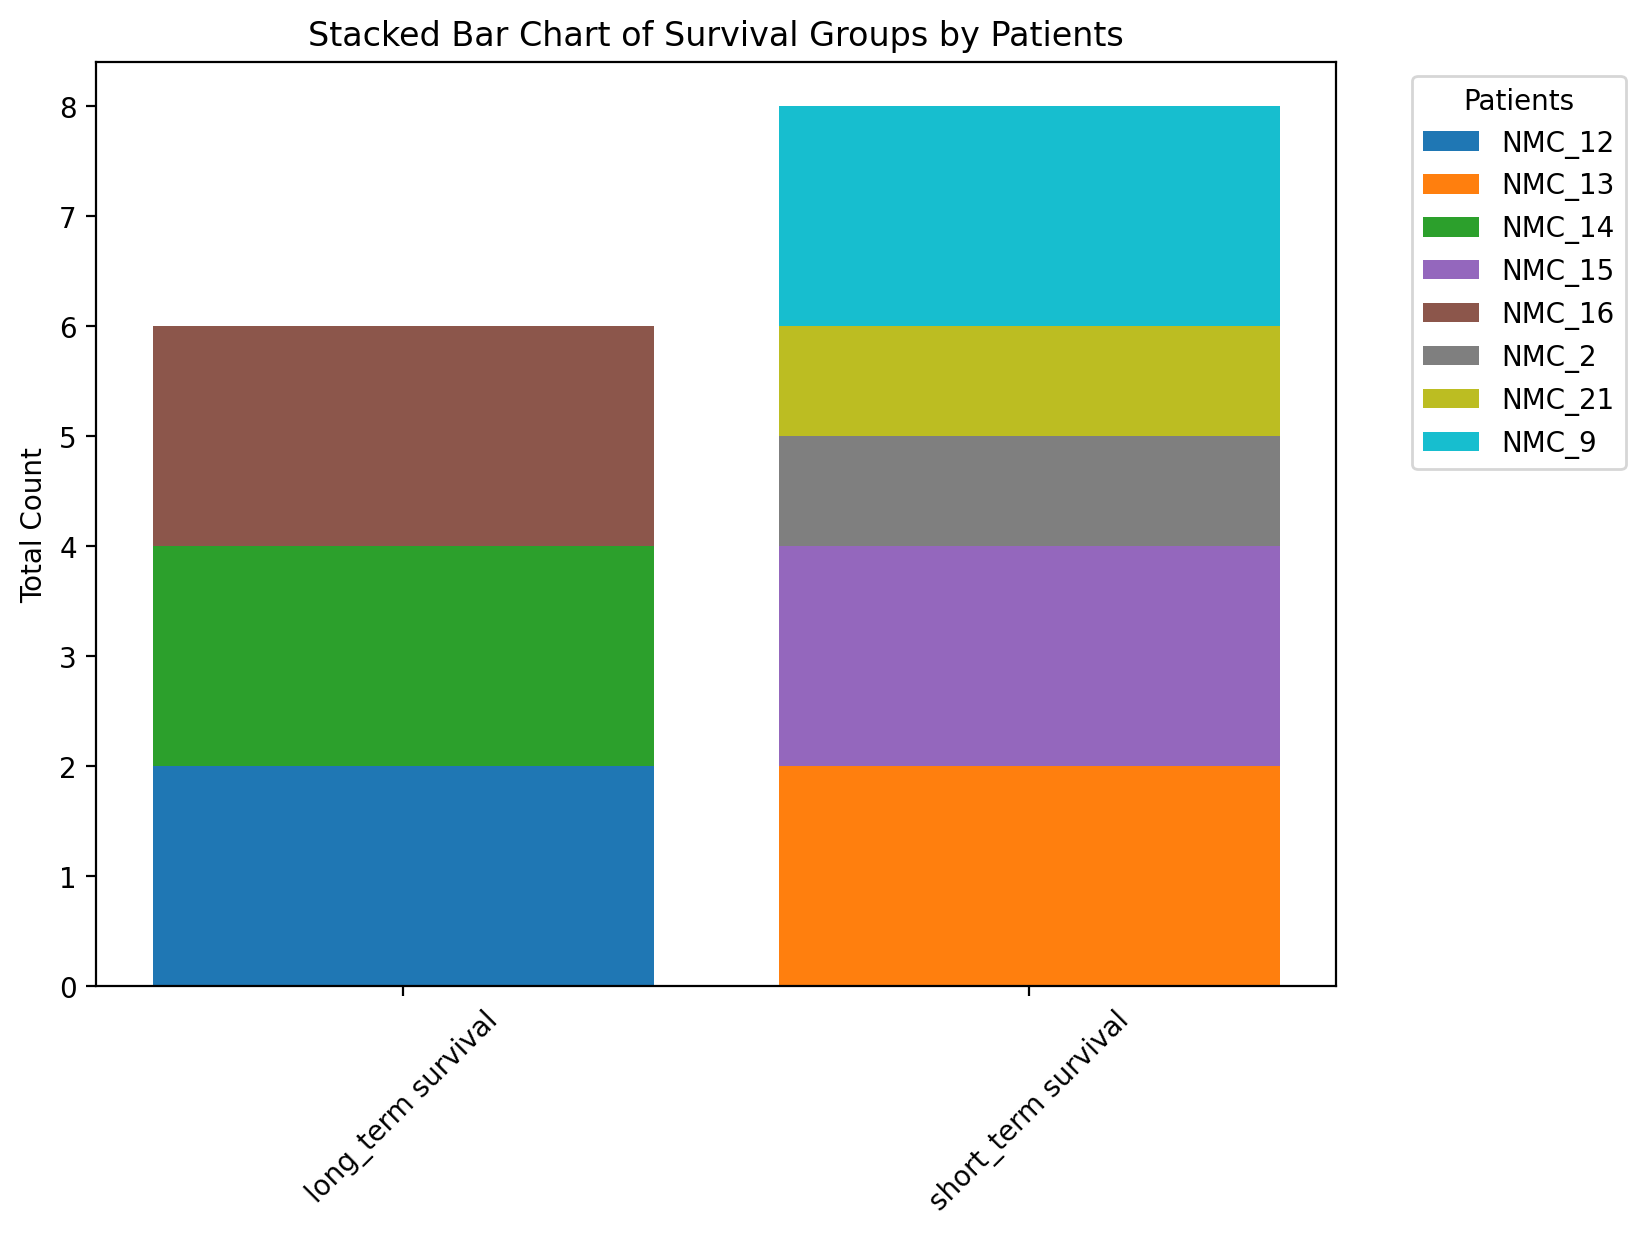

In [5]:
#barchart based on the outcome_group total number, divided by patients.
outcome_group_count = patients_metadata.groupby(['outcome_group', "patient_ID"]).size().reset_index(name='count')
outcome_group_count
pivot_df = outcome_group_count.pivot(index="patient_ID", columns="outcome_group", values="count").fillna(0)

#/ Get unique survival groups
survival_groups = pivot_df.columns

# Initialize figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors for different patients
colors = plt.cm.tab10(np.linspace(0, 1, len(pivot_df)))  # Get distinct colors

# Stack the bars for each survival group
bottoms = {group: np.zeros(len(survival_groups)) for group in survival_groups}

for i, patient in enumerate(pivot_df.index):
    values = pivot_df.loc[patient]
    ax.bar(survival_groups, values, label=patient, bottom=bottoms[survival_groups[0]], color=colors[i])
    bottoms[survival_groups[0]] += values

# Labels & legend
ax.set_ylabel("Total Count")
ax.set_title("Stacked Bar Chart of Survival Groups by Patients")
ax.legend(title="Patients", bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


# Check the Cell type Distribution

## Remove the trash cells

In [18]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    meta = pd.read_csv(roi / 'metadata.csv')
    if "Trash" not in meta["cell_type"].unique():
        print("No trash cells in metadata")
        continue
    else:
        pass
    meta = meta.loc[meta["cell_type"] != "Trash"]
    exp = exp[exp["cell_id"].isin(meta.cell_id)]
    #export csvs
    exp.to_csv(roi / 'exp.csv', index=False)
    meta.to_csv(roi / 'metadata.csv', index=False)

No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata
No trash cells in metadata


## Extract the names of all cell types

In [19]:
# Create a list of all cell types
all_cell_types = []  
for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    all_cell_types.extend(meta["cell_type"].unique())
# Create a set of unique cell types
all_cell_types = sorted(set(all_cell_types))   
# Create a DataFrame with all cell types and initialize counts to zero
meta = pd.read_csv(roi_list[0] / 'metadata.csv')
meta_counts = meta["cell_type"].value_counts()
for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
sorted_order = meta_counts.index  # Extract the index order from a reference DataFrame
all_cell_types = list(sorted_order)
all_cell_types

['Tumor_cells',
 'Actin+_cells',
 'NFC',
 'Endothelial_cells',
 'CD4+_T_cells',
 'M1_macrophages',
 'DCs',
 'M1_M2_macrophages',
 'Mast_cells',
 'M2_macrophages',
 'CD8+_T_cells',
 'Treg_T_cells',
 'Plasma_cells',
 'Lymphatic_endothelial_cells',
 'MDSCs',
 'B_cells',
 'Granulocytes',
 'Epithelial_cells',
 'NK_cells']

## Plot cell types distribution

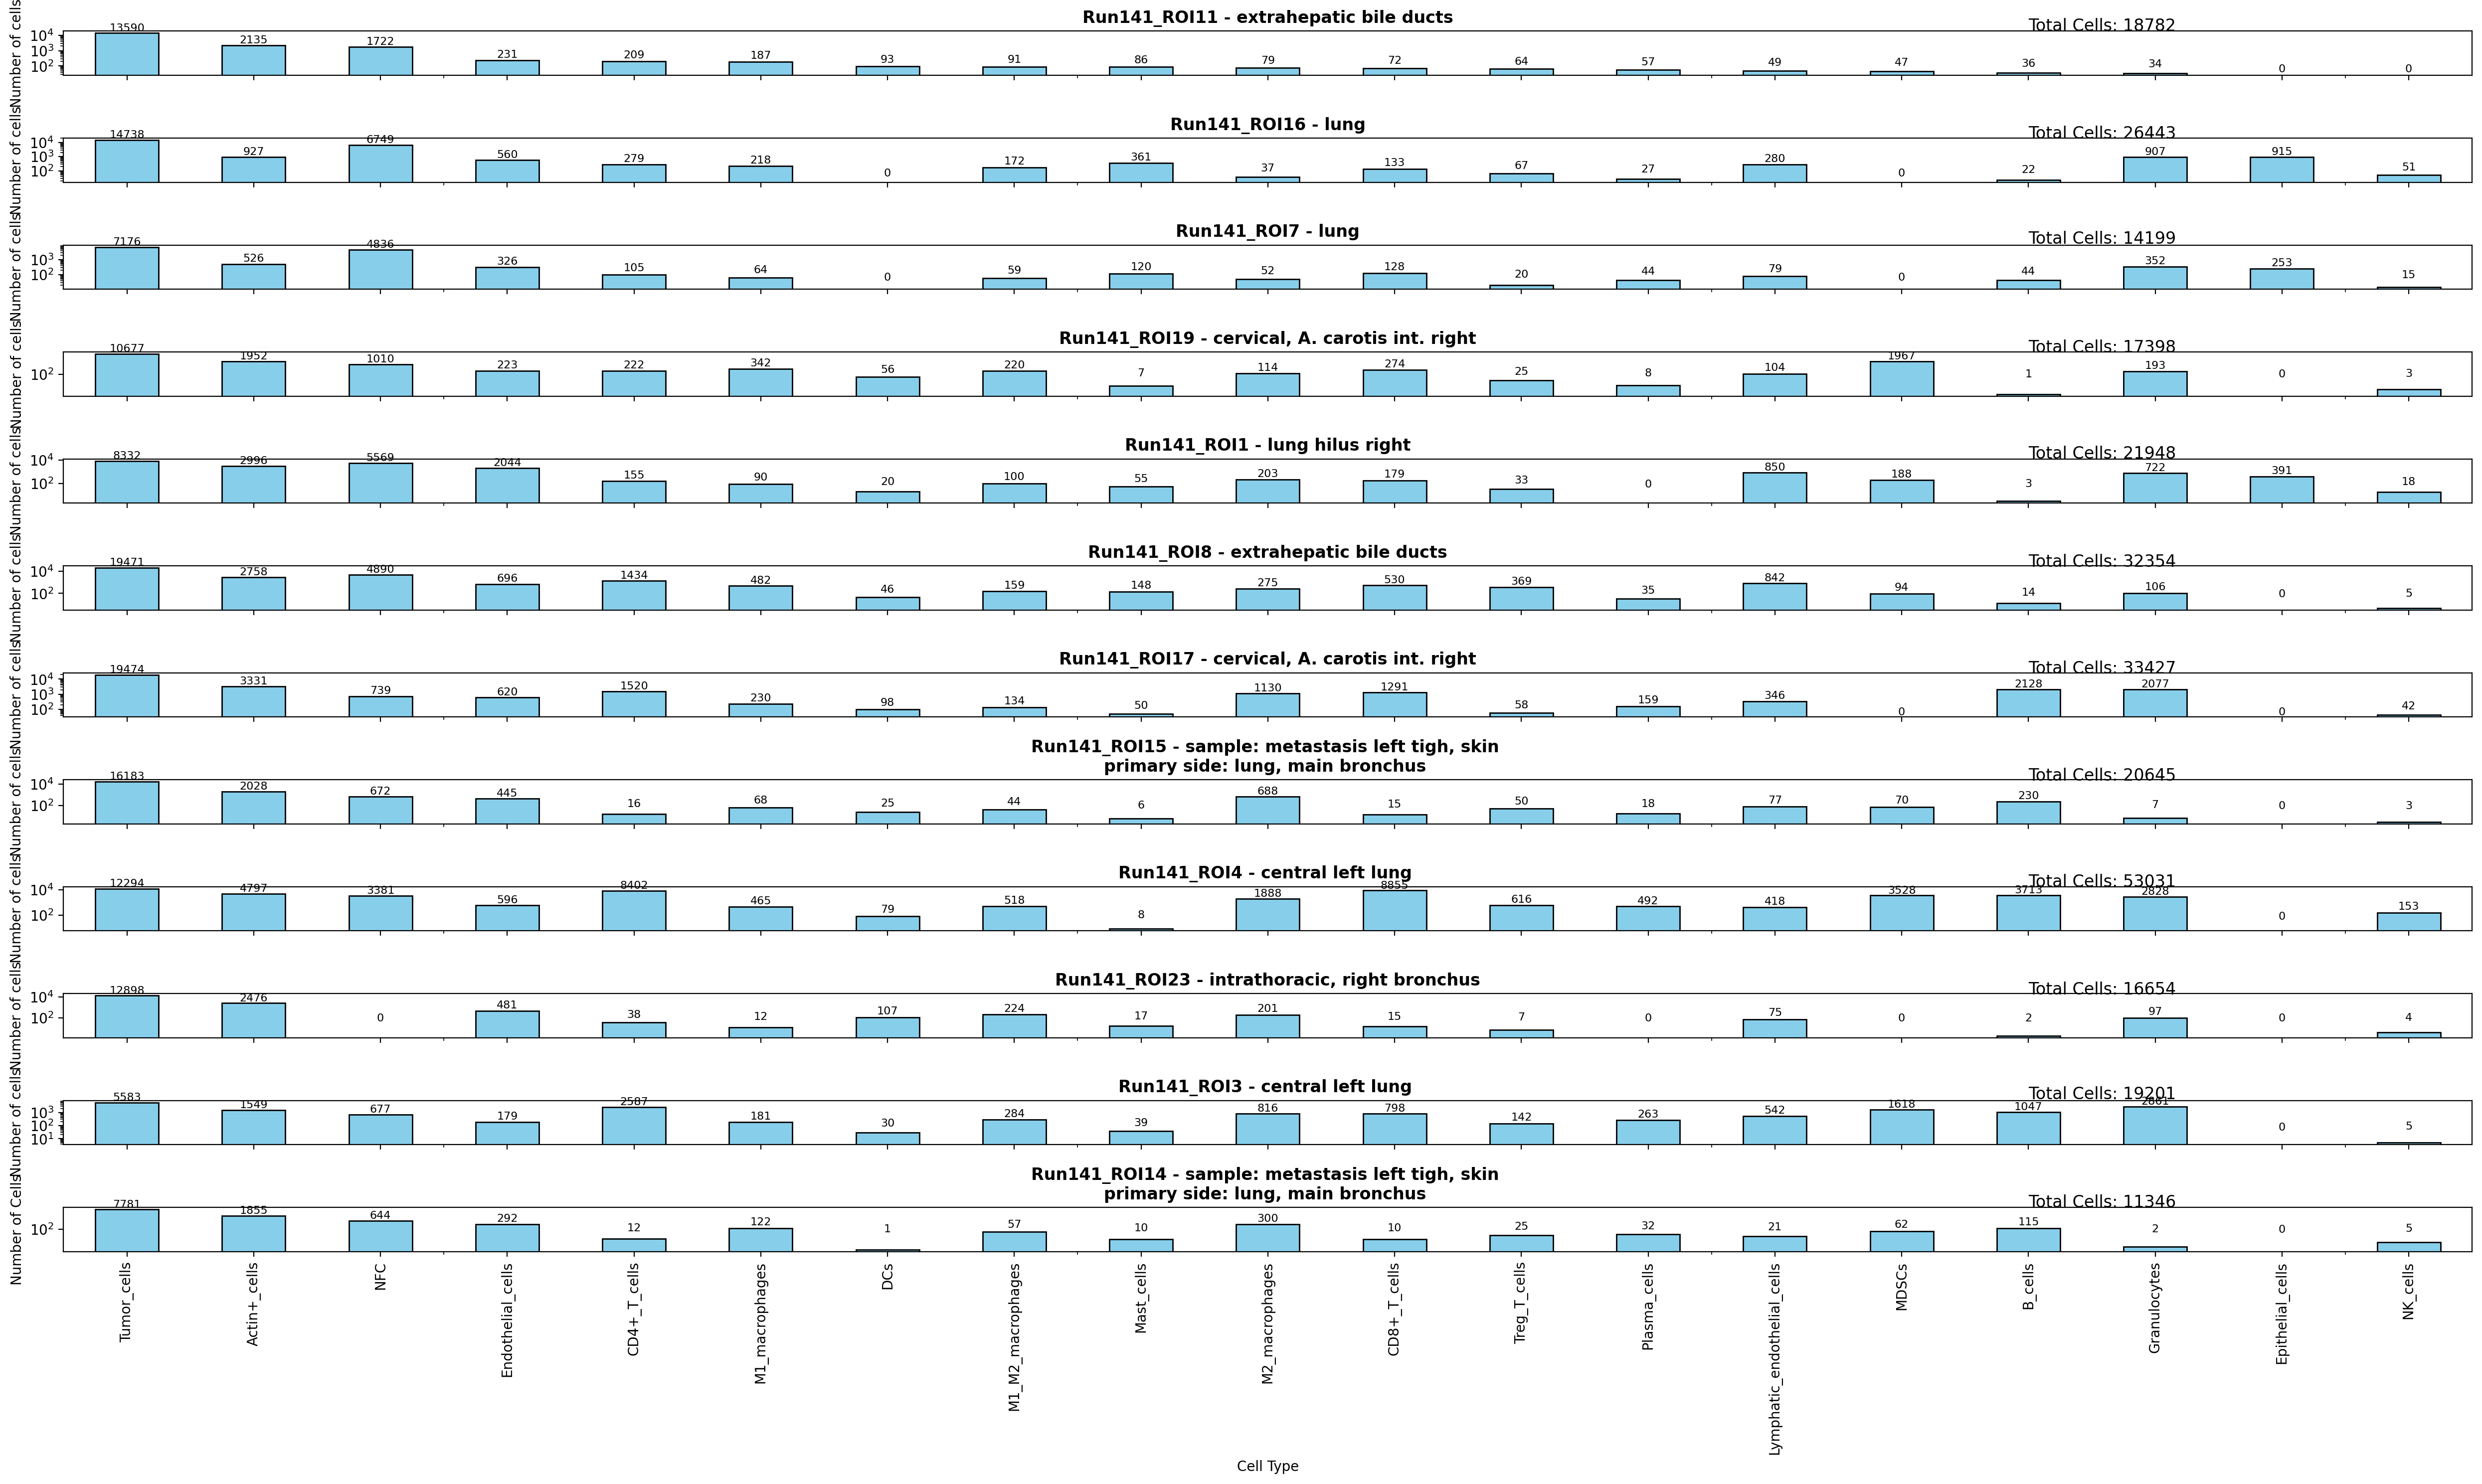

In [21]:
fig, axes = plt.subplots(len(roi_list), 1, figsize=(25, 15), sharex=True)

for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    meta_counts = meta["cell_type"].value_counts()
    patients_metadata = pd.read_csv(metadata_dir / 'new_patients_metadata.csv')
    site = patients_metadata[patients_metadata["exp_name"] == roi.name]["site"].values[0]
    #fill cell types with 0 if they are not present in the metadata
    for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
    meta_counts = meta_counts.reindex(all_cell_types)
    #make bar plot with percentages of meta_counts
    meta_counts.plot(kind='bar', ax=axes[i], color = "skyblue", edgecolor='black')
    axes[i].text(15, np.max(meta_counts) + 5000 , f'Total Cells: {meta_counts.sum()}', fontsize=12)
    #add the number of cells in each cell type on the bar
    for j, count in enumerate(meta_counts):
        axes[i].text(j, count + 30, count, ha='center', va='bottom', fontsize=8)
    axes[i].set_title(f"{roi.name} - {site}", fontweight='bold')
    axes[i].set_ylabel('Number of cells')
    #log transform the y-axis
    axes[i].set_yscale('log')

axes[-1].set_xticks(range(len(all_cell_types)))
axes[-1].set_xticklabels(all_cell_types, rotation=90)
axes[i].set_xlabel("Cell Type")
axes[i].set_ylabel("Number of Cells")

fig.tight_layout()

In [62]:
#Plot the cell types percentages across all ROIs
all_meta_counts = []
for roi in roi_list:
    meta = pd.read_csv(roi / 'metadata.csv')
    meta_counts = meta["cell_type"].value_counts()
    #fill cell types with 0 if they are not present in the metadata
    for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
    meta_counts = meta_counts.reindex(all_cell_types)
    #Create a dataframe with the ROI names
    meta_counts = meta_counts.to_frame().reset_index()
    counts_sum = meta_counts["count"].sum()
    meta_counts["percentage"] = meta_counts["count"] / counts_sum * 100
    meta_counts["roi"] = roi.name
    all_meta_counts.append(meta_counts)

all_meta_counts = pd.concat(all_meta_counts)

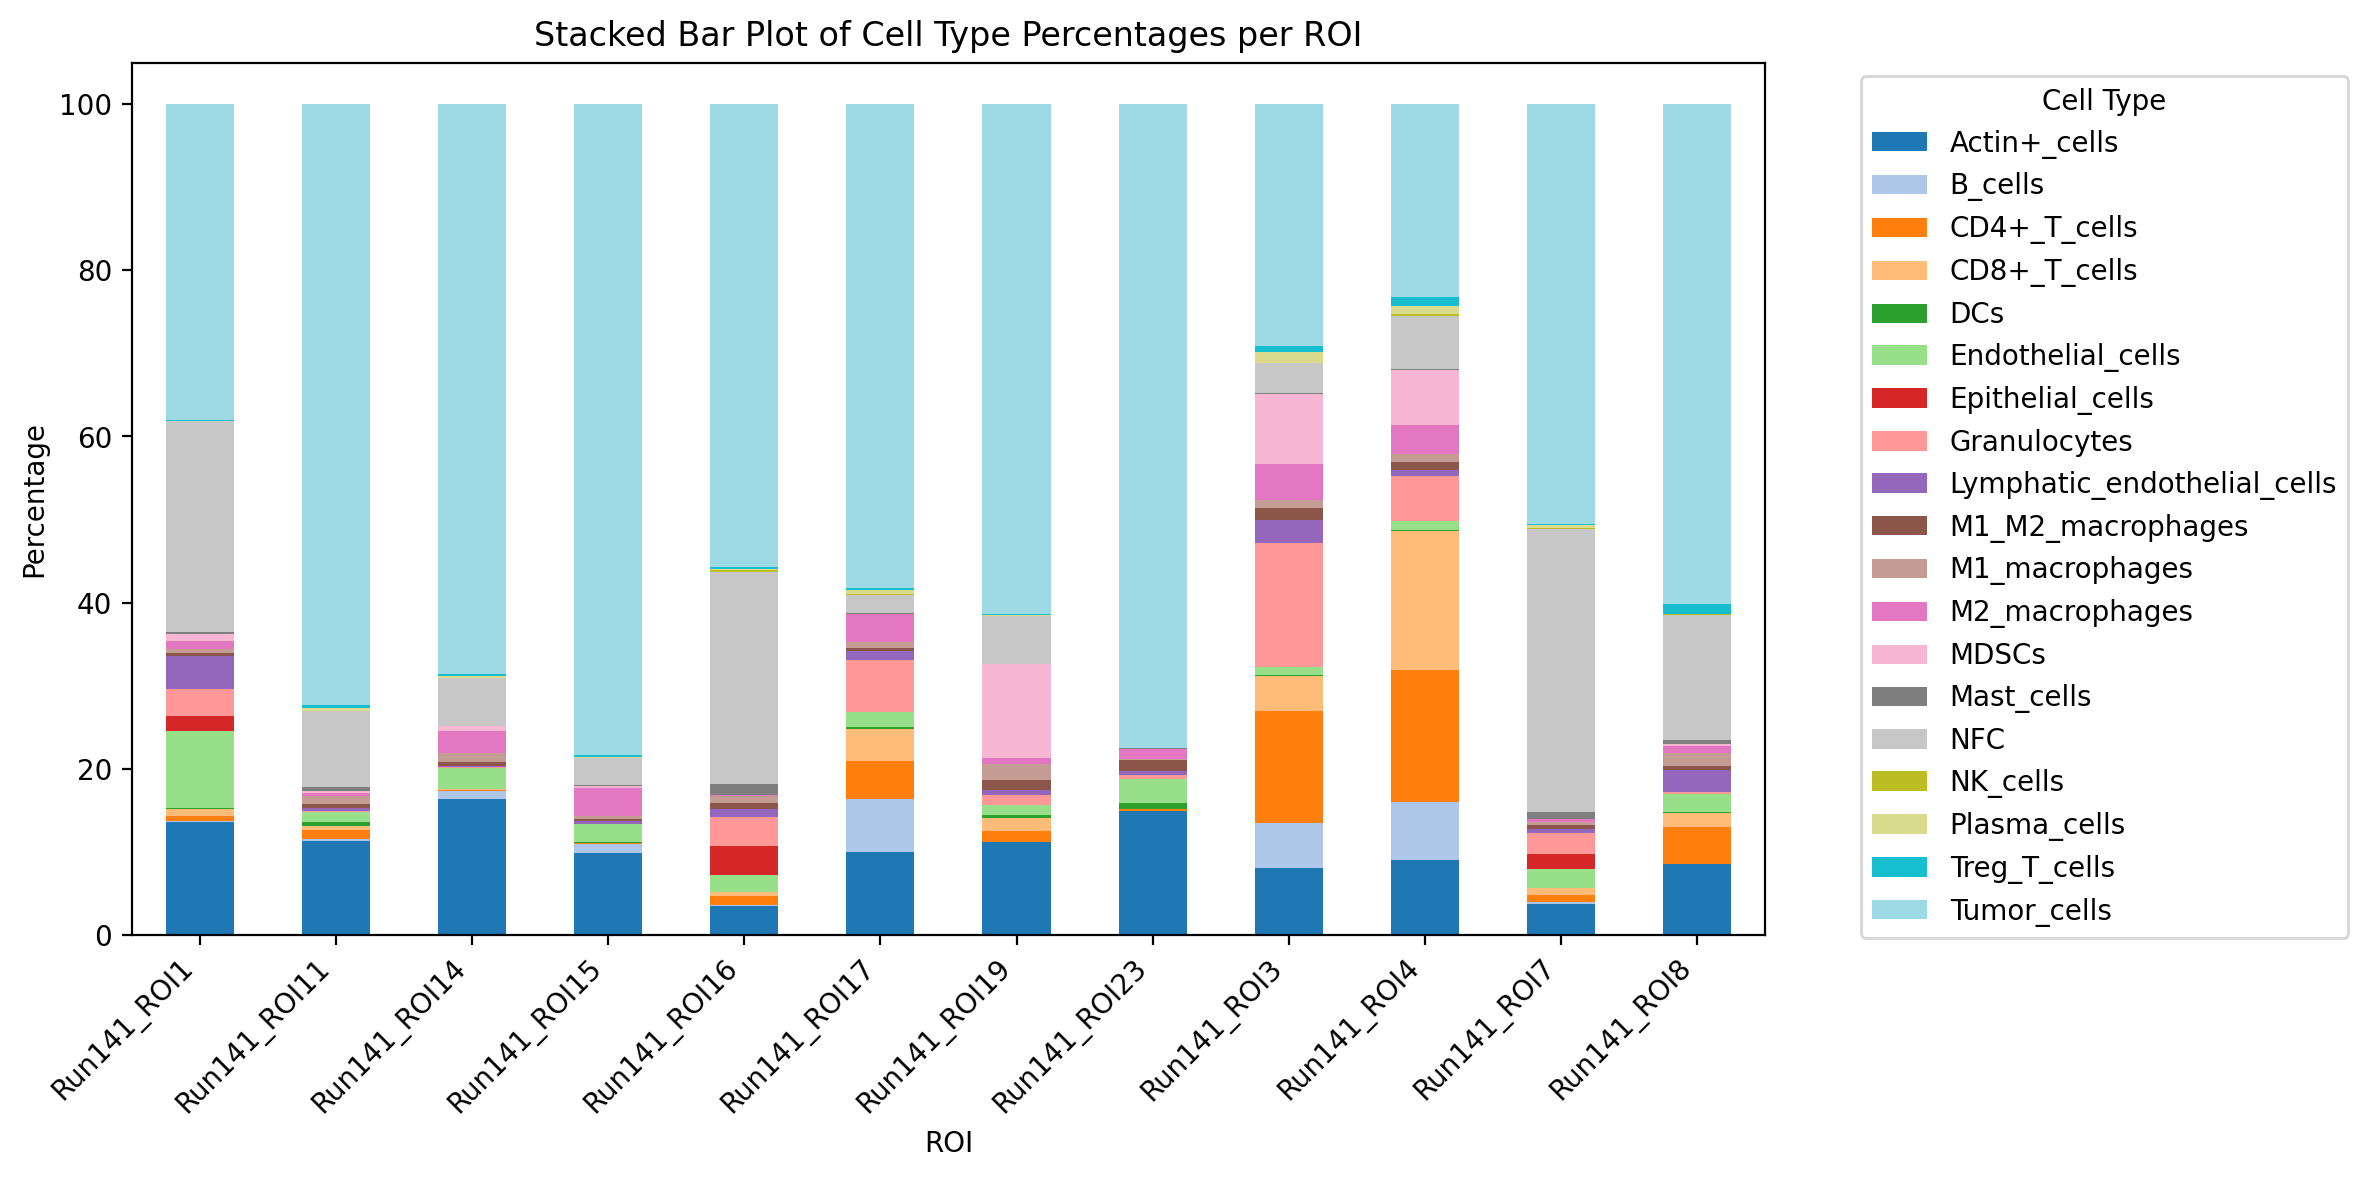

In [78]:
df_pivot = all_meta_counts.pivot(index="roi", columns="cell_type", values="percentage").fillna(0)

# Plotting
ax = df_pivot.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")

# Labels and formatting
plt.ylabel("Percentage")
plt.xlabel("ROI")
plt.title("Stacked Bar Plot of Cell Type Percentages per ROI")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Show plot
plt.show()

# Antibodies QC

## Load the antibody panel 

In [22]:
#Read the antibodies list
antibodies = pd.read_excel(metadata_dir/"Run141_Ab_panel.xlsx", sheet_name=["IO core panel", "Add-on Panel"])
#Concatenate the two sheets
antibodies = pd.concat(antibodies, ignore_index=True)
#Fix the column names
antibodies["ab_clone"] = antibodies["ab_clone"].str.replace("__", " ")
antibodies["ab_clone"] = antibodies["ab_clone"].str.replace("_", " ")
antibodies[antibodies.duplicated(subset='ab_clone')] = antibodies[antibodies.duplicated(subset='ab_clone')].astype(str).apply(lambda x: x + " 1")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_2484/2474731241.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['4.0 1' '6.0 1' '15.0 1' '18.0 1' '25.0 1' 'nan 1']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  antibodies[antibodies.duplicated(subset='ab_clone')] = antibodies[antibodies.duplicated(subset='ab_clone')].astype(str).apply(lambda x: x + " 1")


## Remove the antibodies with low staining quality

In [32]:
low_antibodies = antibodies[antibodies["staining quality"] == "LOW"].ab_clone
medium_antibodies = antibodies[antibodies["staining quality"] == "MEDIUM"].ab_clone
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    if set(low_antibodies).issubset(exp.columns):
        pass
    else:
        print(f"Low quality antibodies not found in {roi.name}")
        continue
    exp.drop(columns=low_antibodies, inplace=True)
    exp.to_csv(roi / 'exp.csv', index=False)

Low quality antibodies not found in Run141_ROI11
Low quality antibodies not found in Run141_ROI16
Low quality antibodies not found in Run141_ROI7
Low quality antibodies not found in Run141_ROI19
Low quality antibodies not found in Run141_ROI1
Low quality antibodies not found in Run141_ROI8
Low quality antibodies not found in Run141_ROI17
Low quality antibodies not found in Run141_ROI15
Low quality antibodies not found in Run141_ROI4
Low quality antibodies not found in Run141_ROI23
Low quality antibodies not found in Run141_ROI3
Low quality antibodies not found in Run141_ROI14


## Remove antibodies not present in all samples


In [33]:
#remove the two antibodies not present in all
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    if "CD279 REA1165 1" in exp.columns:
        exp.drop(columns=["CD279 REA1165 1", "NUT C52B1 2"], inplace=True)
        exp.to_csv(roi / 'exp.csv', index=False)
    else:
        pass
    if "CD279 REA1165 ROI4" in exp.columns:
        exp.drop(columns=["CD279 REA1165 ROI4", "NUT C52B1 ROI4"], inplace=True)
        exp.to_csv(roi / 'exp.csv', index=False)
    else:
        pass

## Checking if the number of antibodies is equal in all datasets

In [35]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    print(len(exp.columns))

83
83
83
83
83
83
83
83
83
83
83
83


## Plot the raw antibodies expression 

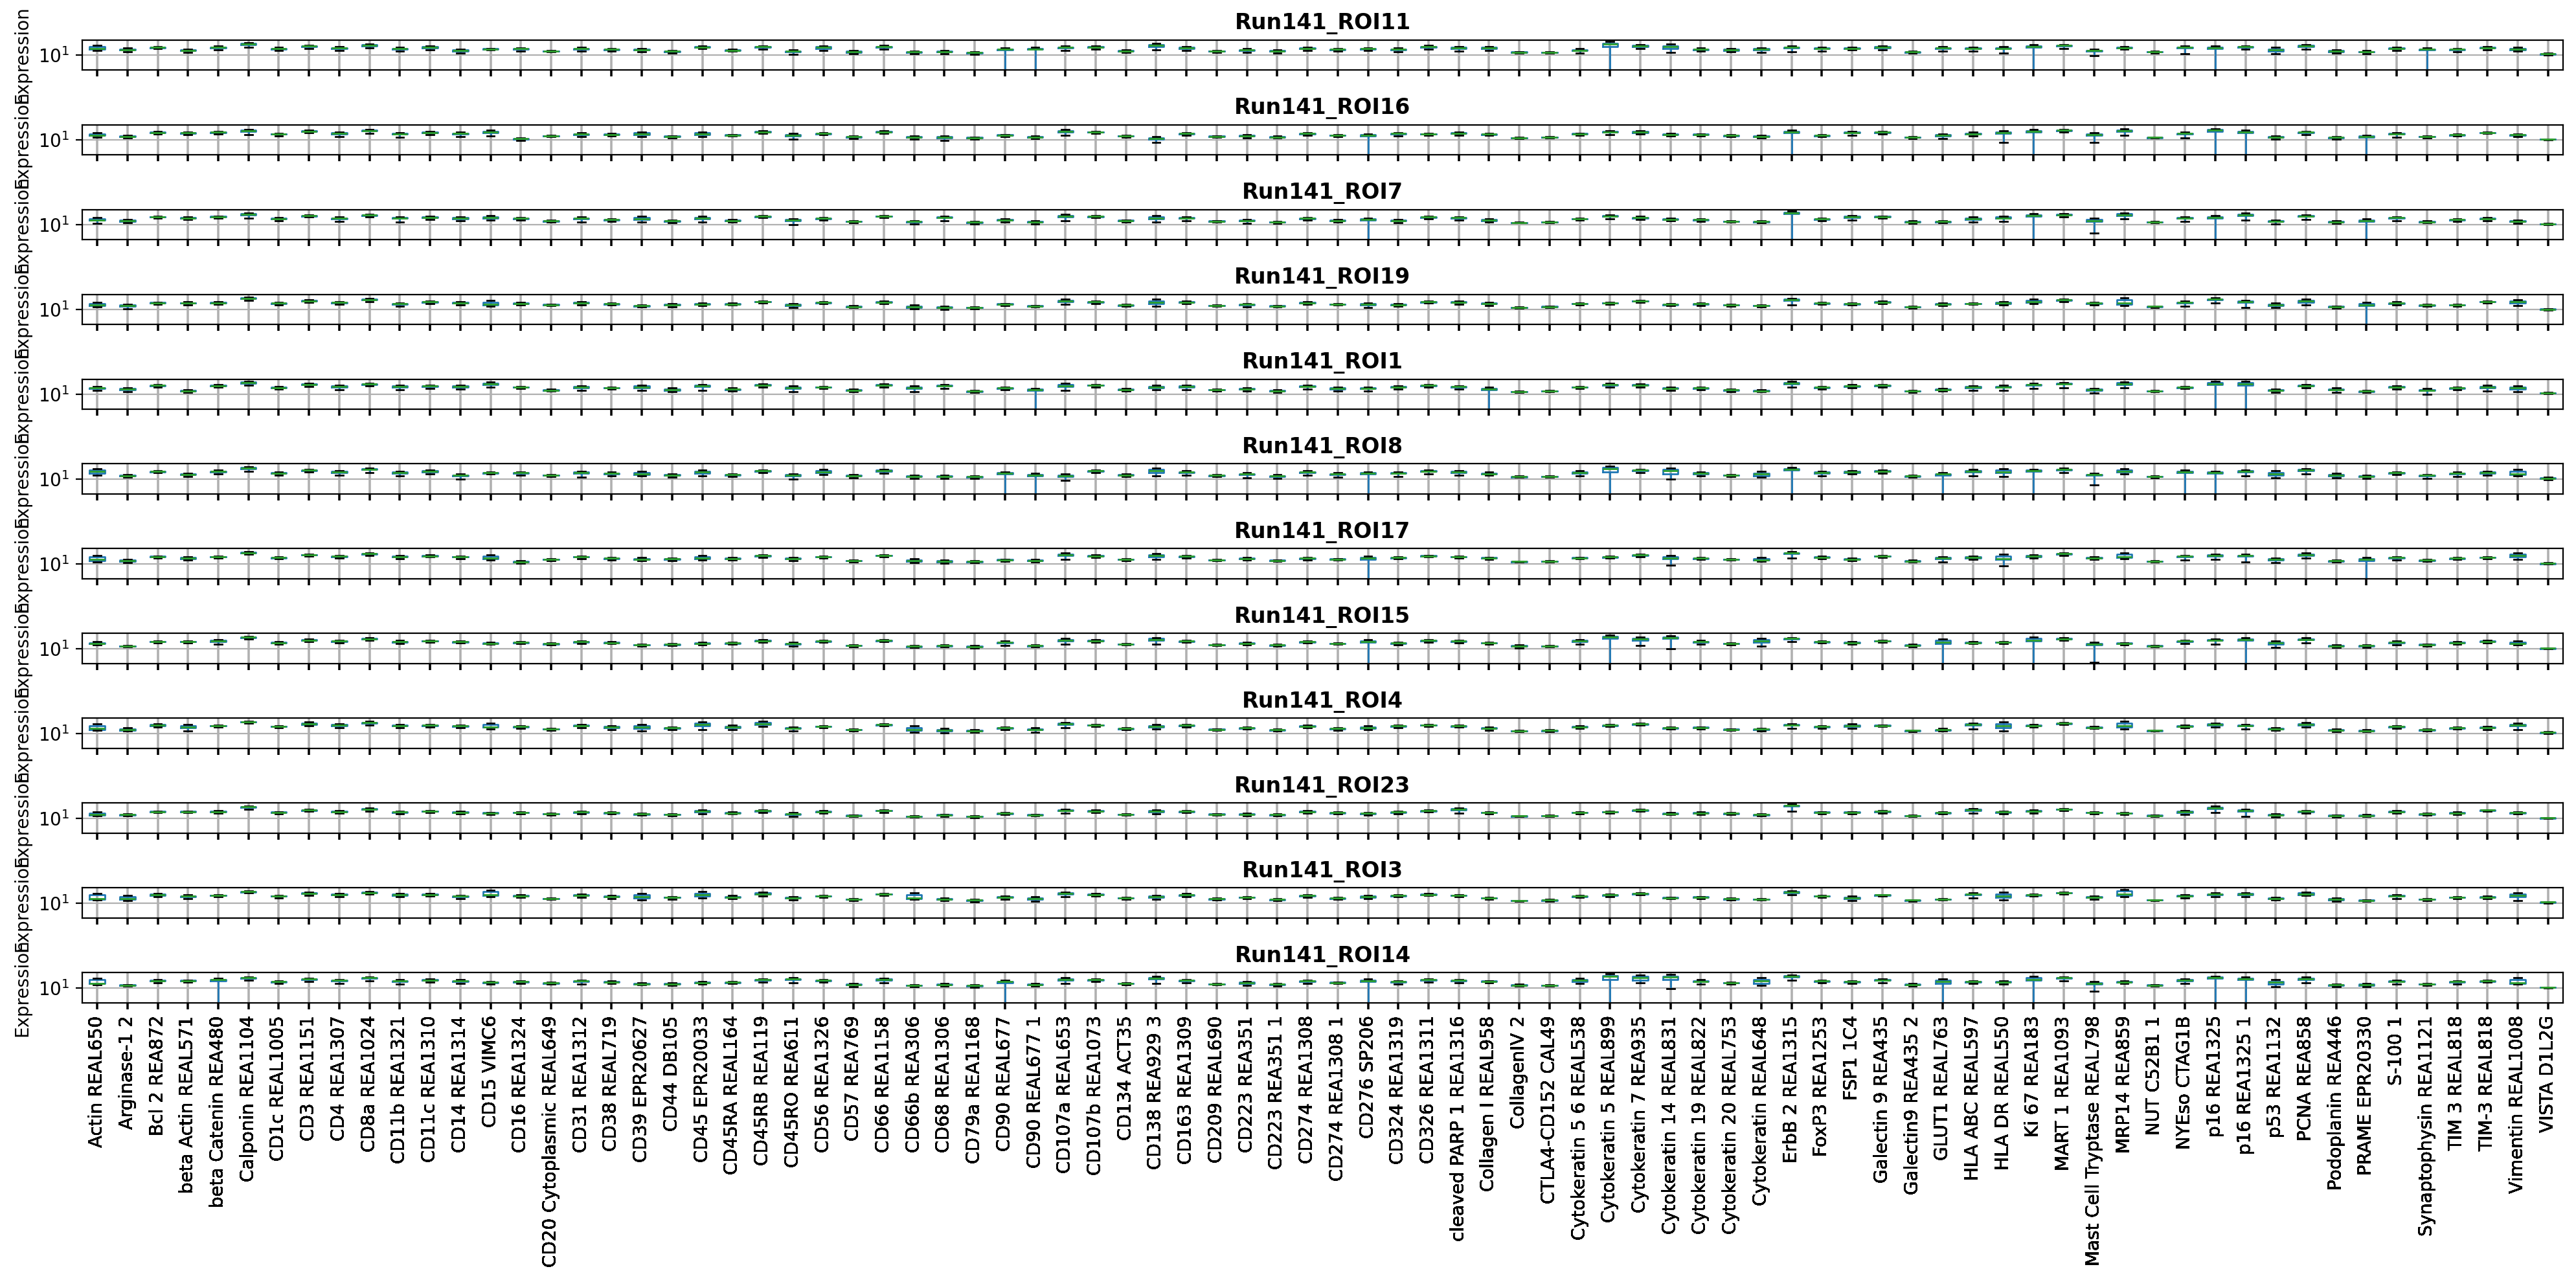

In [37]:
fig, axes = plt.subplots(len(roi_list), 1, figsize=(20, 10), sharex=True, sharey=True)

for i, roi in enumerate(roi_list):
    exp = pd.read_csv(roi / 'exp.csv')
    exp.iloc[:,1:].boxplot(ax=axes[i], rot=90, showfliers=False)
    axes[i].set_title(roi.name, fontweight='bold')
    axes[i].set_ylabel('Expression')
    axes[i].set_yscale('log')

fig.tight_layout()

## Plotting the histograms of the lowly expressed markers

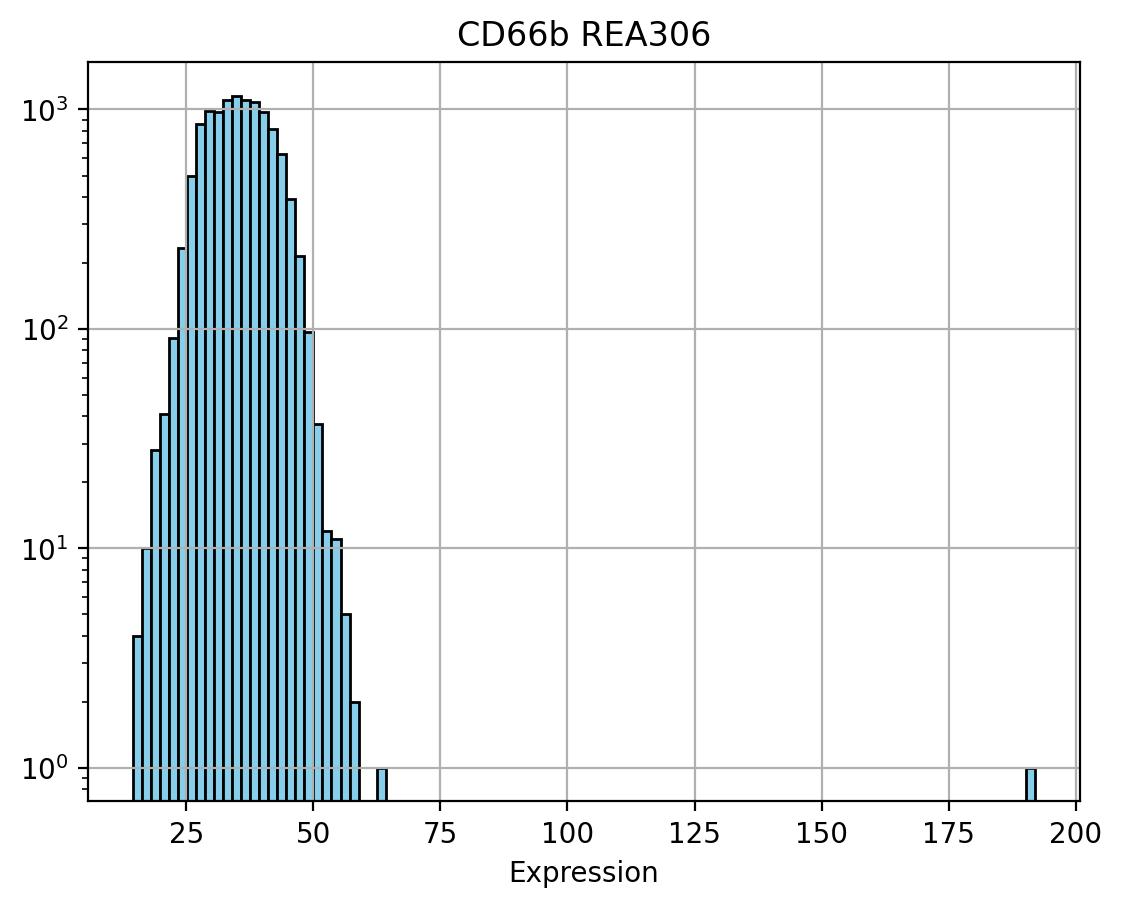

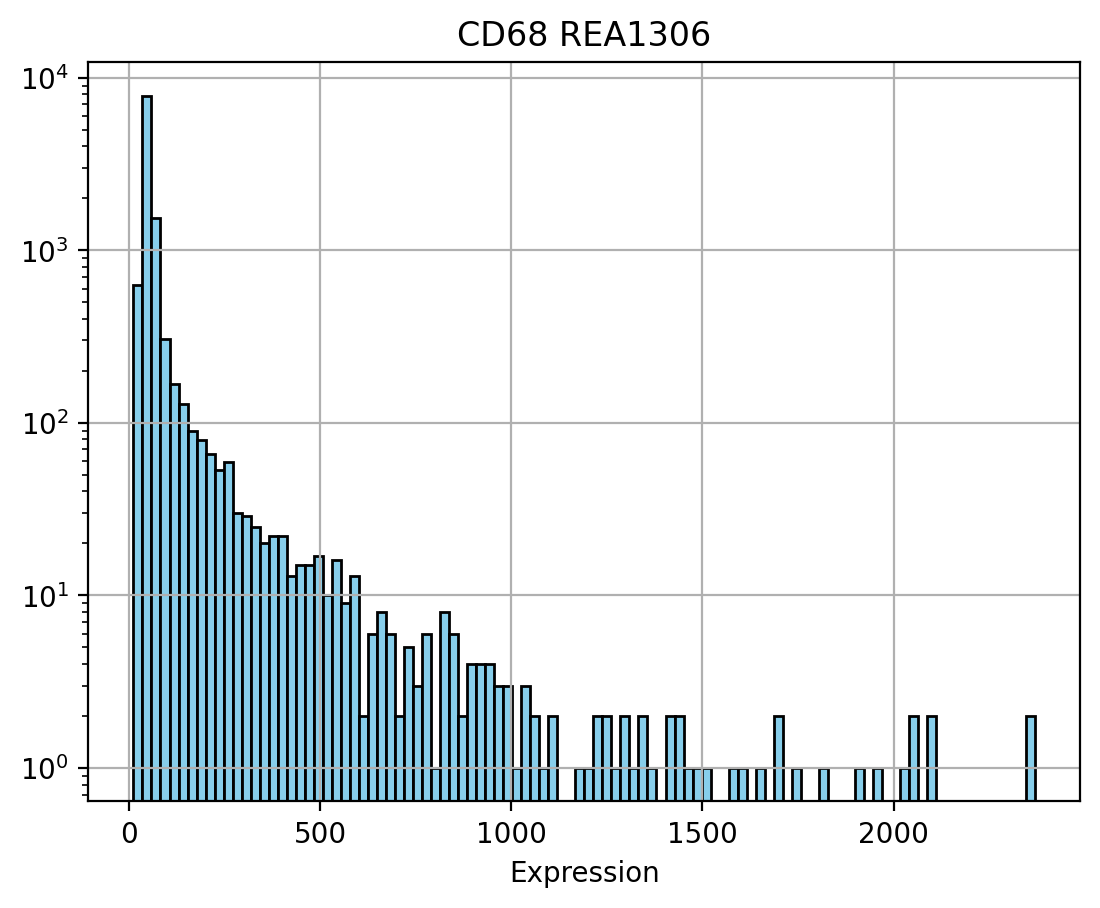

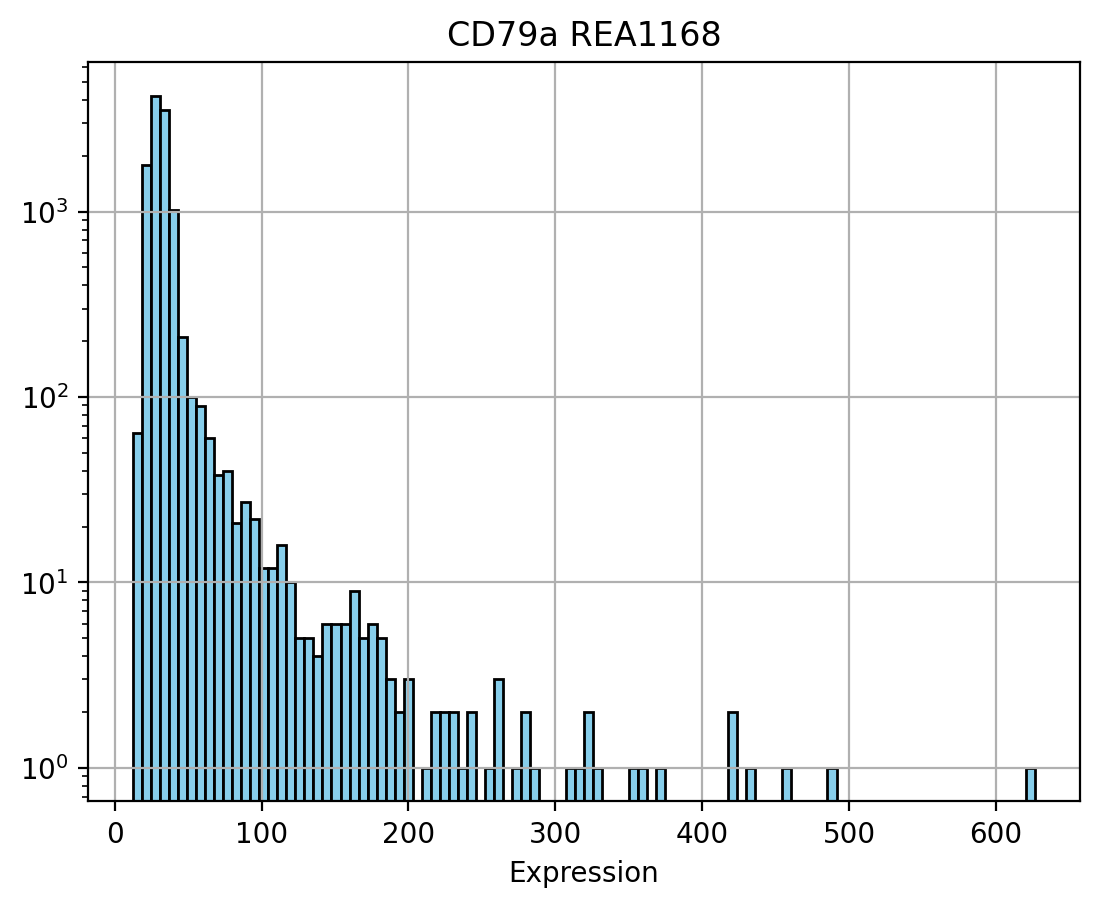

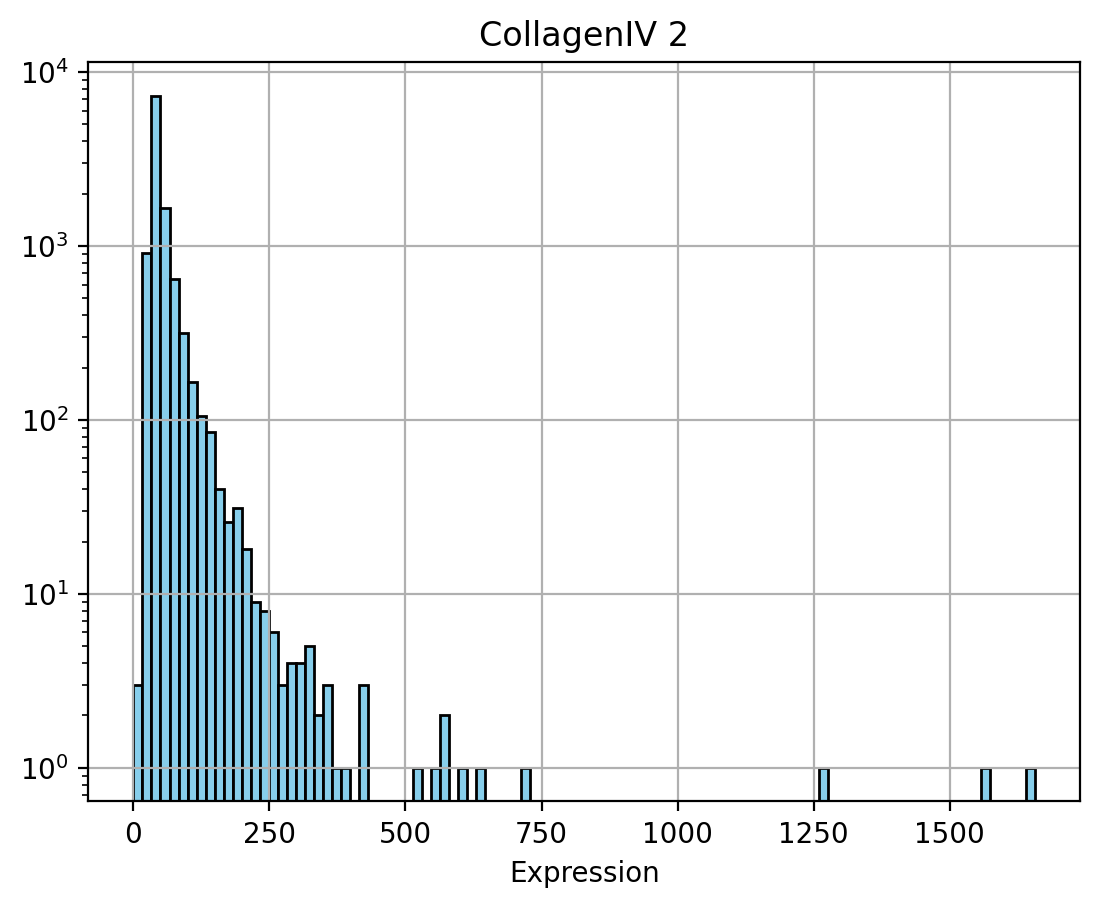

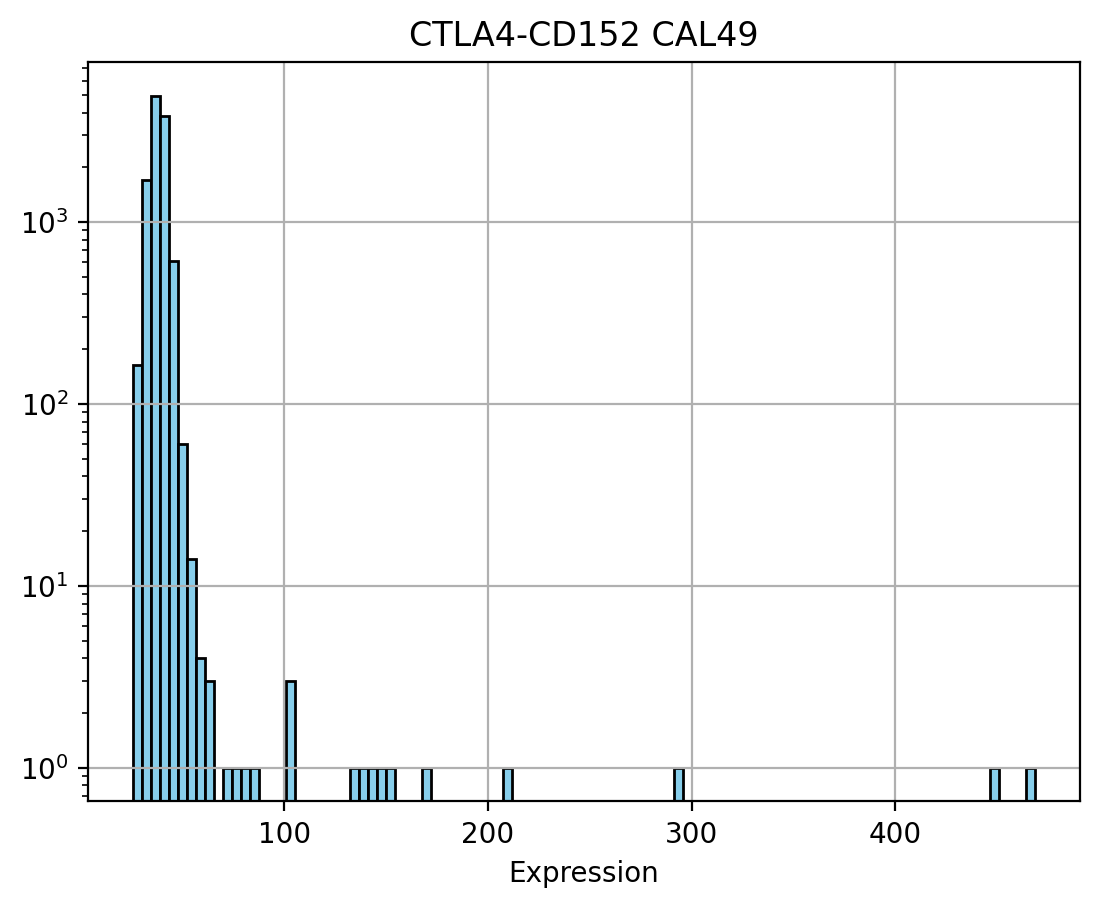

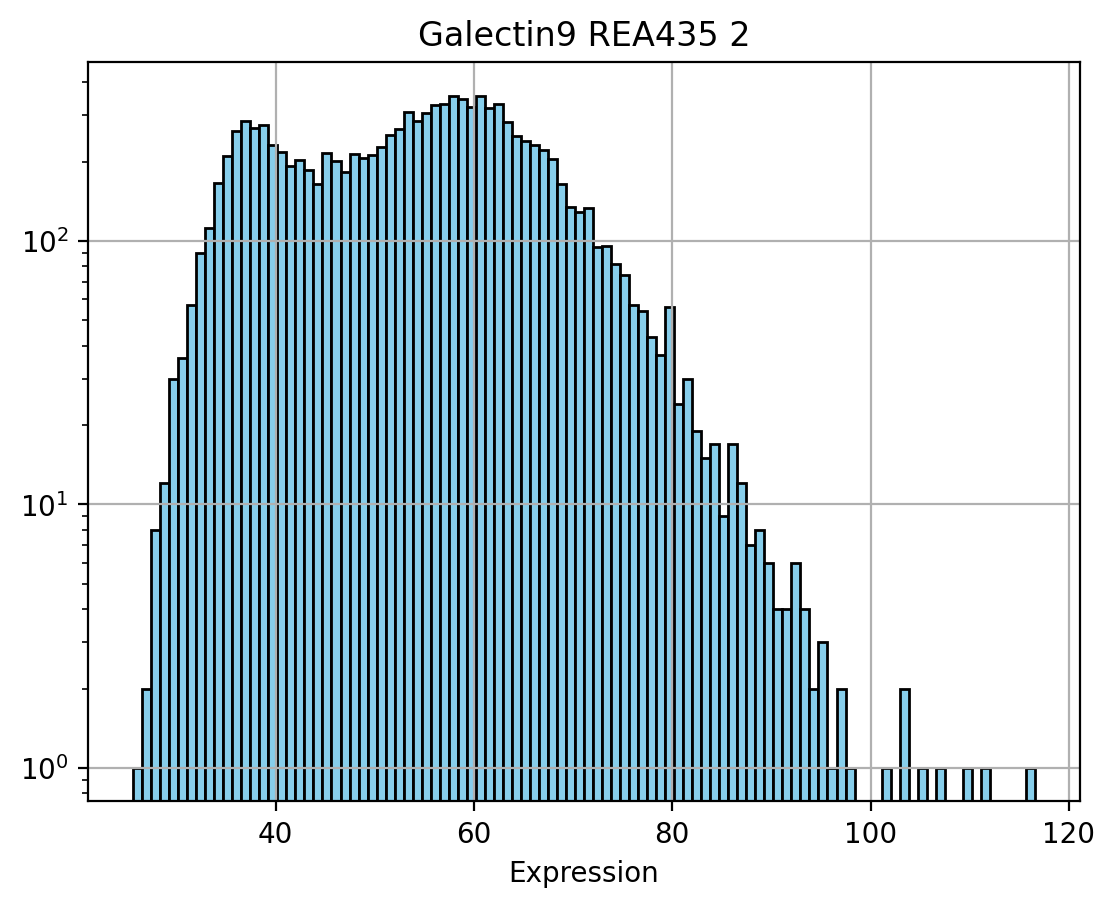

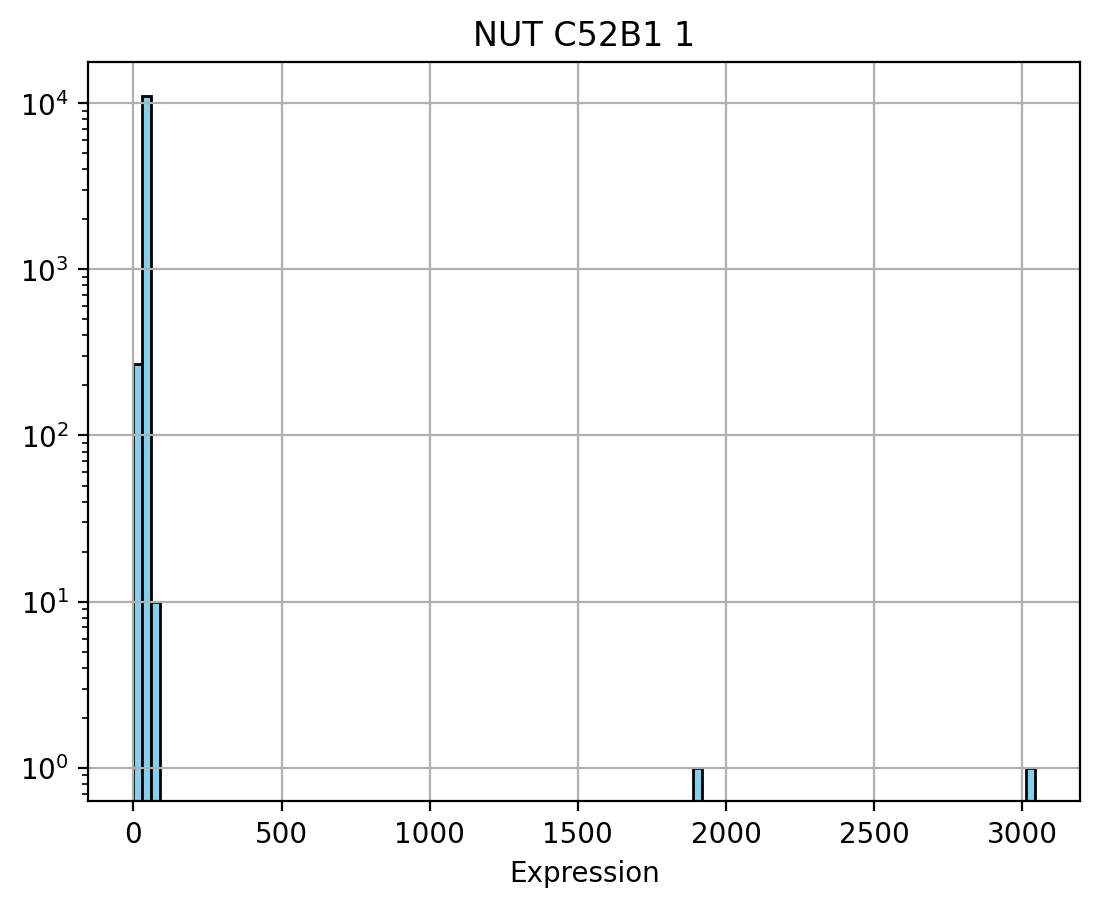

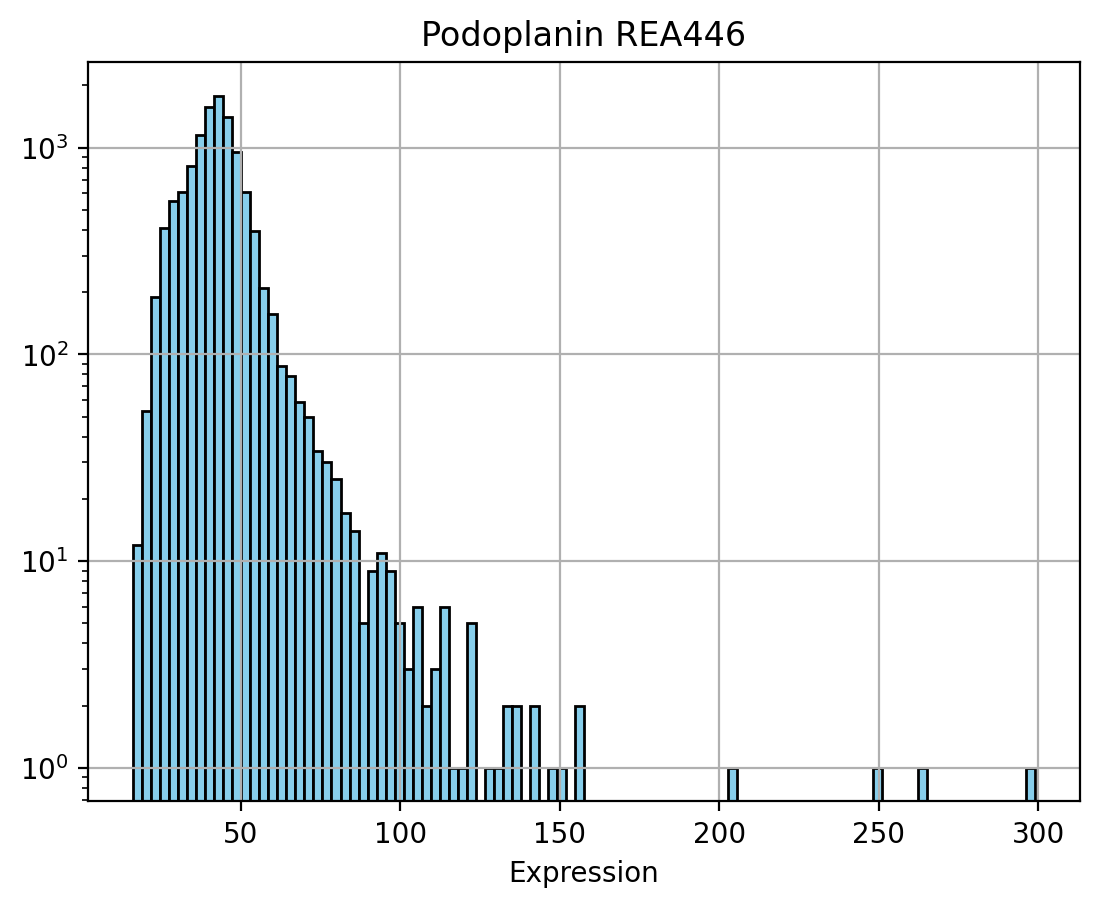

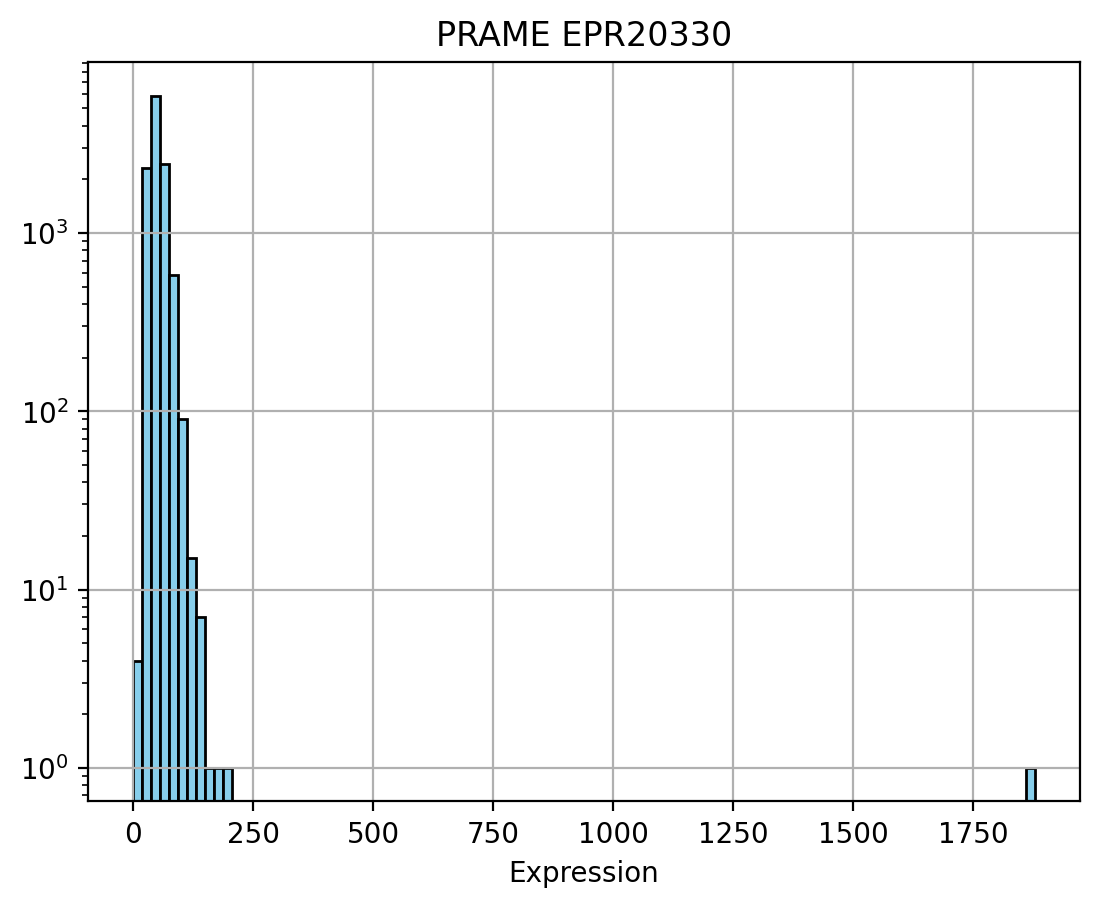

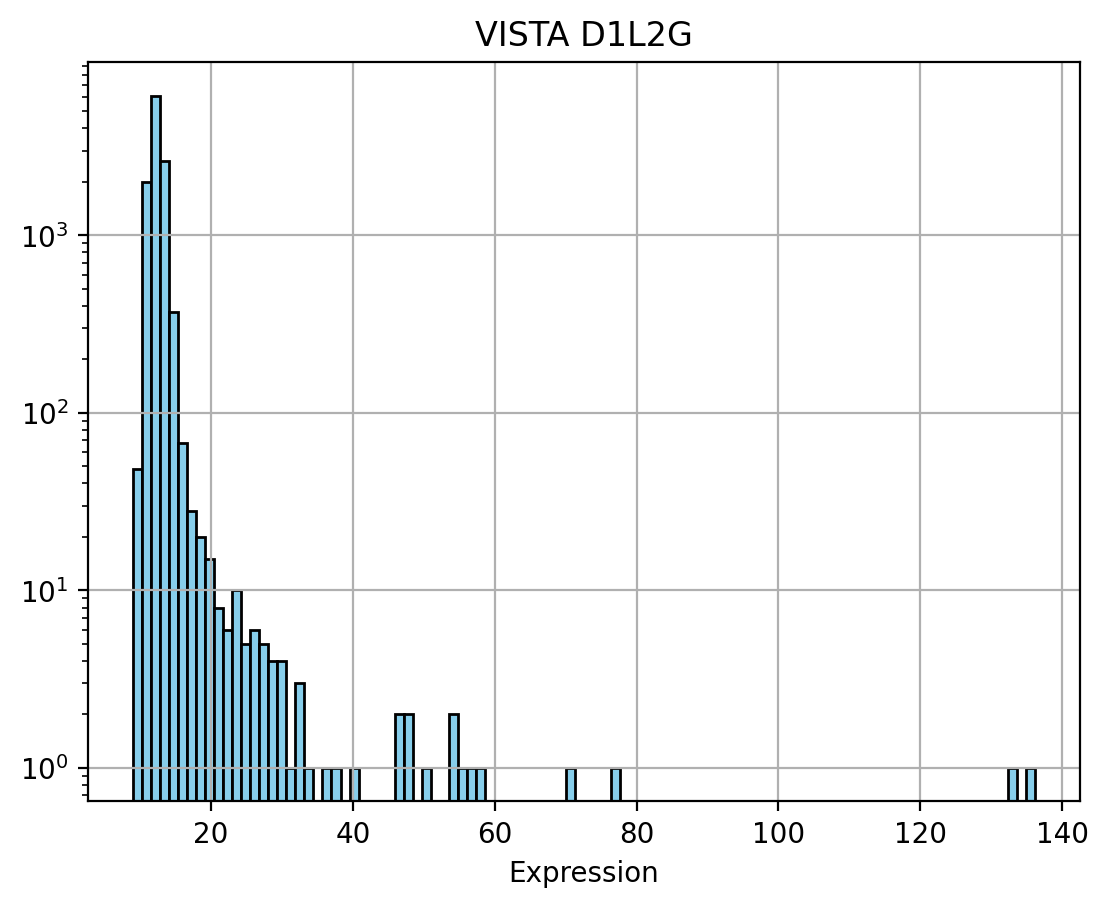

In [ ]:
all_exp = []
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    exp.drop(columns=["cell_id"], inplace=True)
    exp = exp.median(axis=0).to_frame().T
    exp.insert(0, "exp_name", roi.name)
    all_exp.append(exp)
all_exp = pd.concat(all_exp, ignore_index=True)
all_exp_mean = all_exp.iloc[:,1:].median(axis=0)
lowly_antibodies = all_exp_mean[all_exp_mean < 50].index

exp = pd.read_csv(roi / 'exp.csv')
for marker in lowly_antibodies:
    exp[marker].hist(bins=100, color='skyblue', edgecolor='black', log=True)
    plt.title(marker)
    plt.xlabel('Expression')
    plt.show()

In [105]:
#thus filter out NUT 
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    if "NUT C52B1 1" not in exp.columns:
        print(f"NUT C52B1 1 not found in {roi.name}")
        continue
    else:
        pass
    exp.drop(columns="NUT C52B1 1", inplace=True)
    exp.to_csv(roi / 'exp.csv', index=False)

## Find duplicated antibodies (different dilutation factors)

In [121]:
duplicated_antibodies = pd.Series([antibody[:-2] for antibody in antibodies["ab_clone"] if antibody.endswith(" 1")])
duplicated_antibodies = duplicated_antibodies.to_numpy()
#add TIM
duplicated_antibodies = np.append(duplicated_antibodies, "TIM")
#remove S100
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "S-100"))
#remove NUT from the duplicated_antibodies
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "NUT C52B1"))
#remove CD279 
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "CD279 REA1165"))
duplicated_antibodies

array(['CD274 REA1308', 'CD223 REA351', 'CD90 REAL677', 'p16 REA1325',
       'TIM'], dtype=object)

## Plot the correlation between the antibody intensity and its diluted version

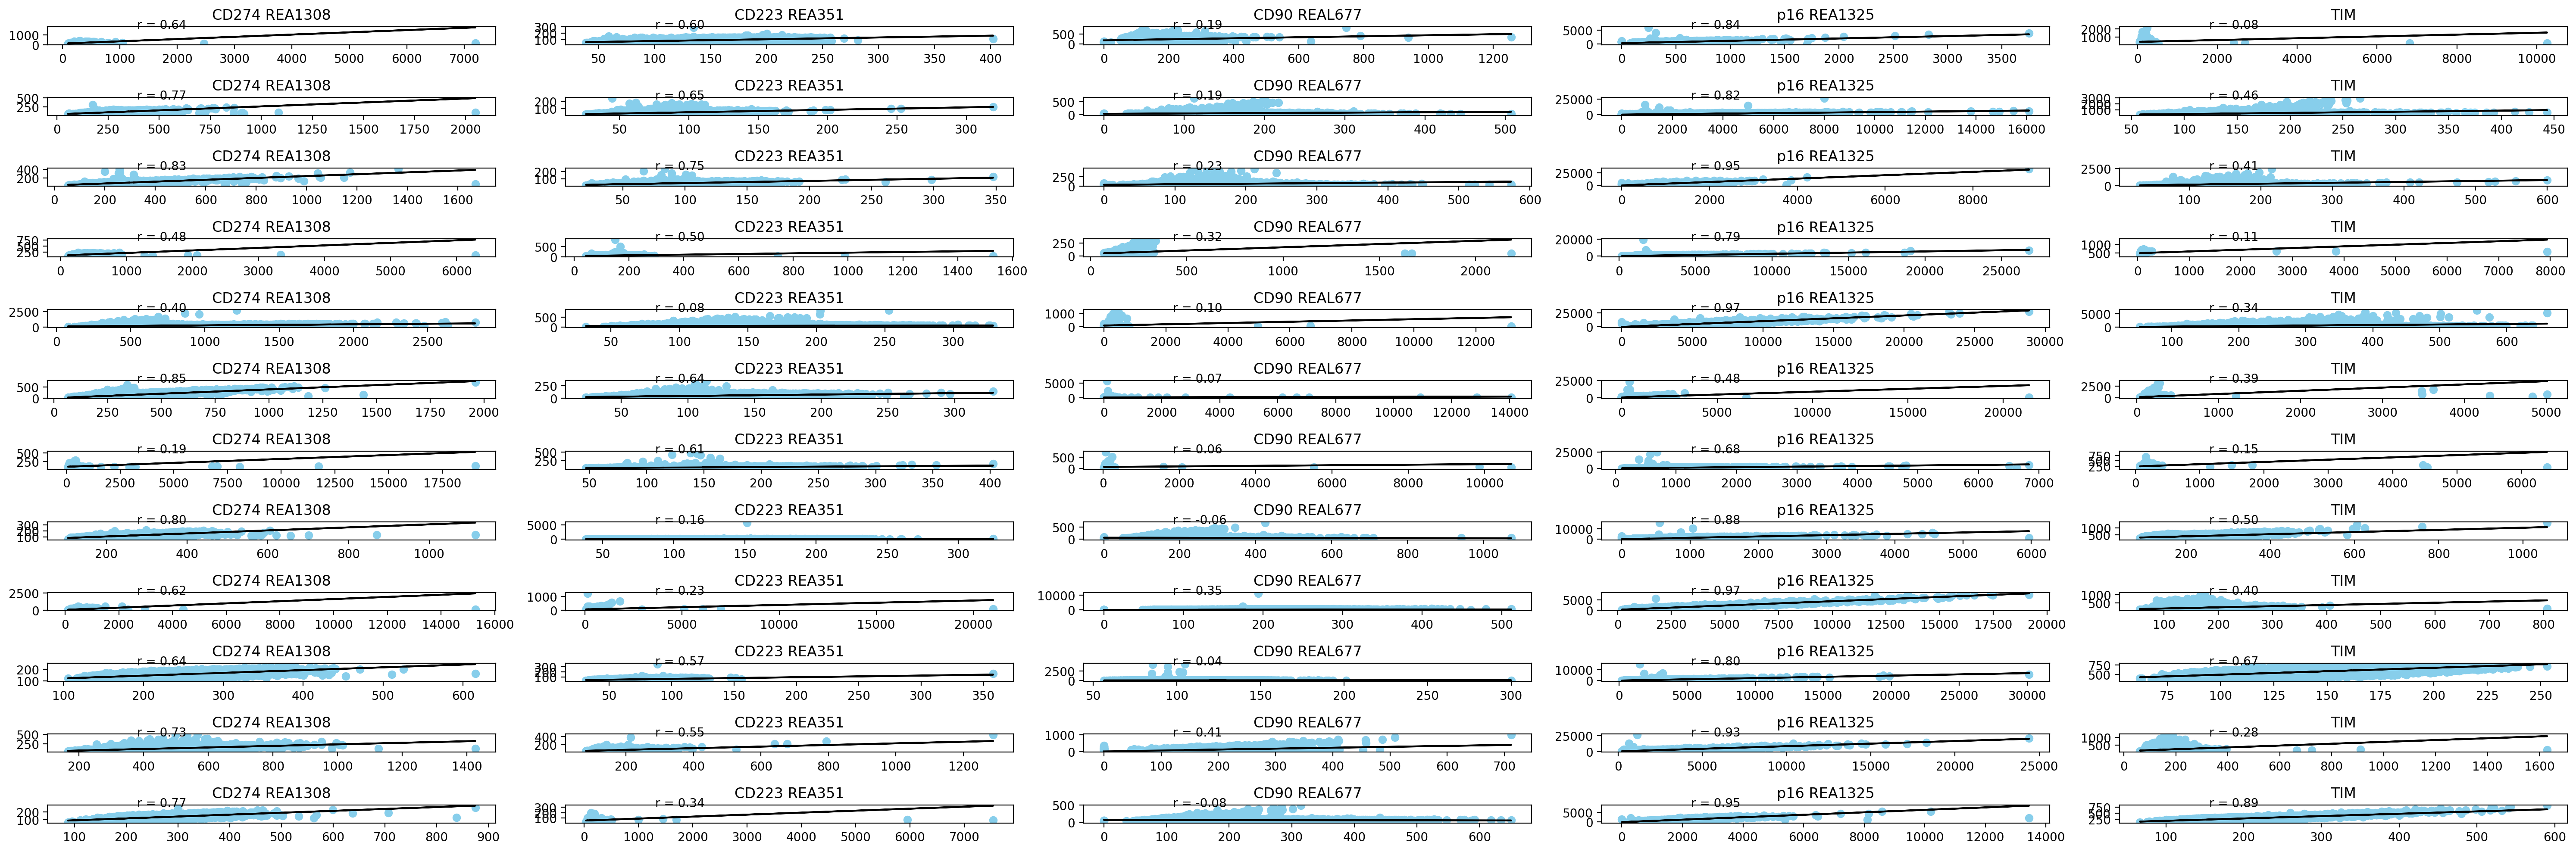

In [116]:
fig, axes = plt.subplots(len(roi_list), len(duplicated_antibodies), figsize=(30, 10))

for i, roi in enumerate(roi_list):
    exp = pd.read_csv(roi / 'exp.csv')
    for j, marker in enumerate(duplicated_antibodies):
        exp_filter = exp.filter(like = marker)
        x = exp_filter.iloc[:,0]
        y = exp_filter.iloc[:,1]
        axes[i,j].scatter(x, y, color='skyblue')
        b, a = np.polyfit(x, y, deg=1)    
        axes[i,j].plot(x, a + b * x, color="k")
        #calculate linear correlation coefficient and add it to the plot
        corr = np.corrcoef(x, y)[0,1]
        axes[i,j].text(0.2, 0.9, "r = {:.2f}".format(corr), transform=axes[i,j].transAxes)
        axes[i,j].set_title(marker)

fig.tight_layout()

In [110]:
# Build a heatmap for the correlation
# Build the correlation dataframe

corr_df = []
for marker in duplicated_antibodies:
    corrs = {}
    for roi in roi_list:
        exp = pd.read_csv(roi / 'exp.csv')
        exp_filter = exp.filter(like = marker)
        x = exp_filter.iloc[:,0]
        y = exp_filter.iloc[:,1]
        cor = np.corrcoef(x, y)[0,1]
        corrs[roi.name] = cor
    corr_df1 = pd.DataFrame.from_dict(corrs, orient='index', columns=[marker])
    corr_df.append(corr_df1)
corr_df = pd.concat(corr_df, axis=1)    

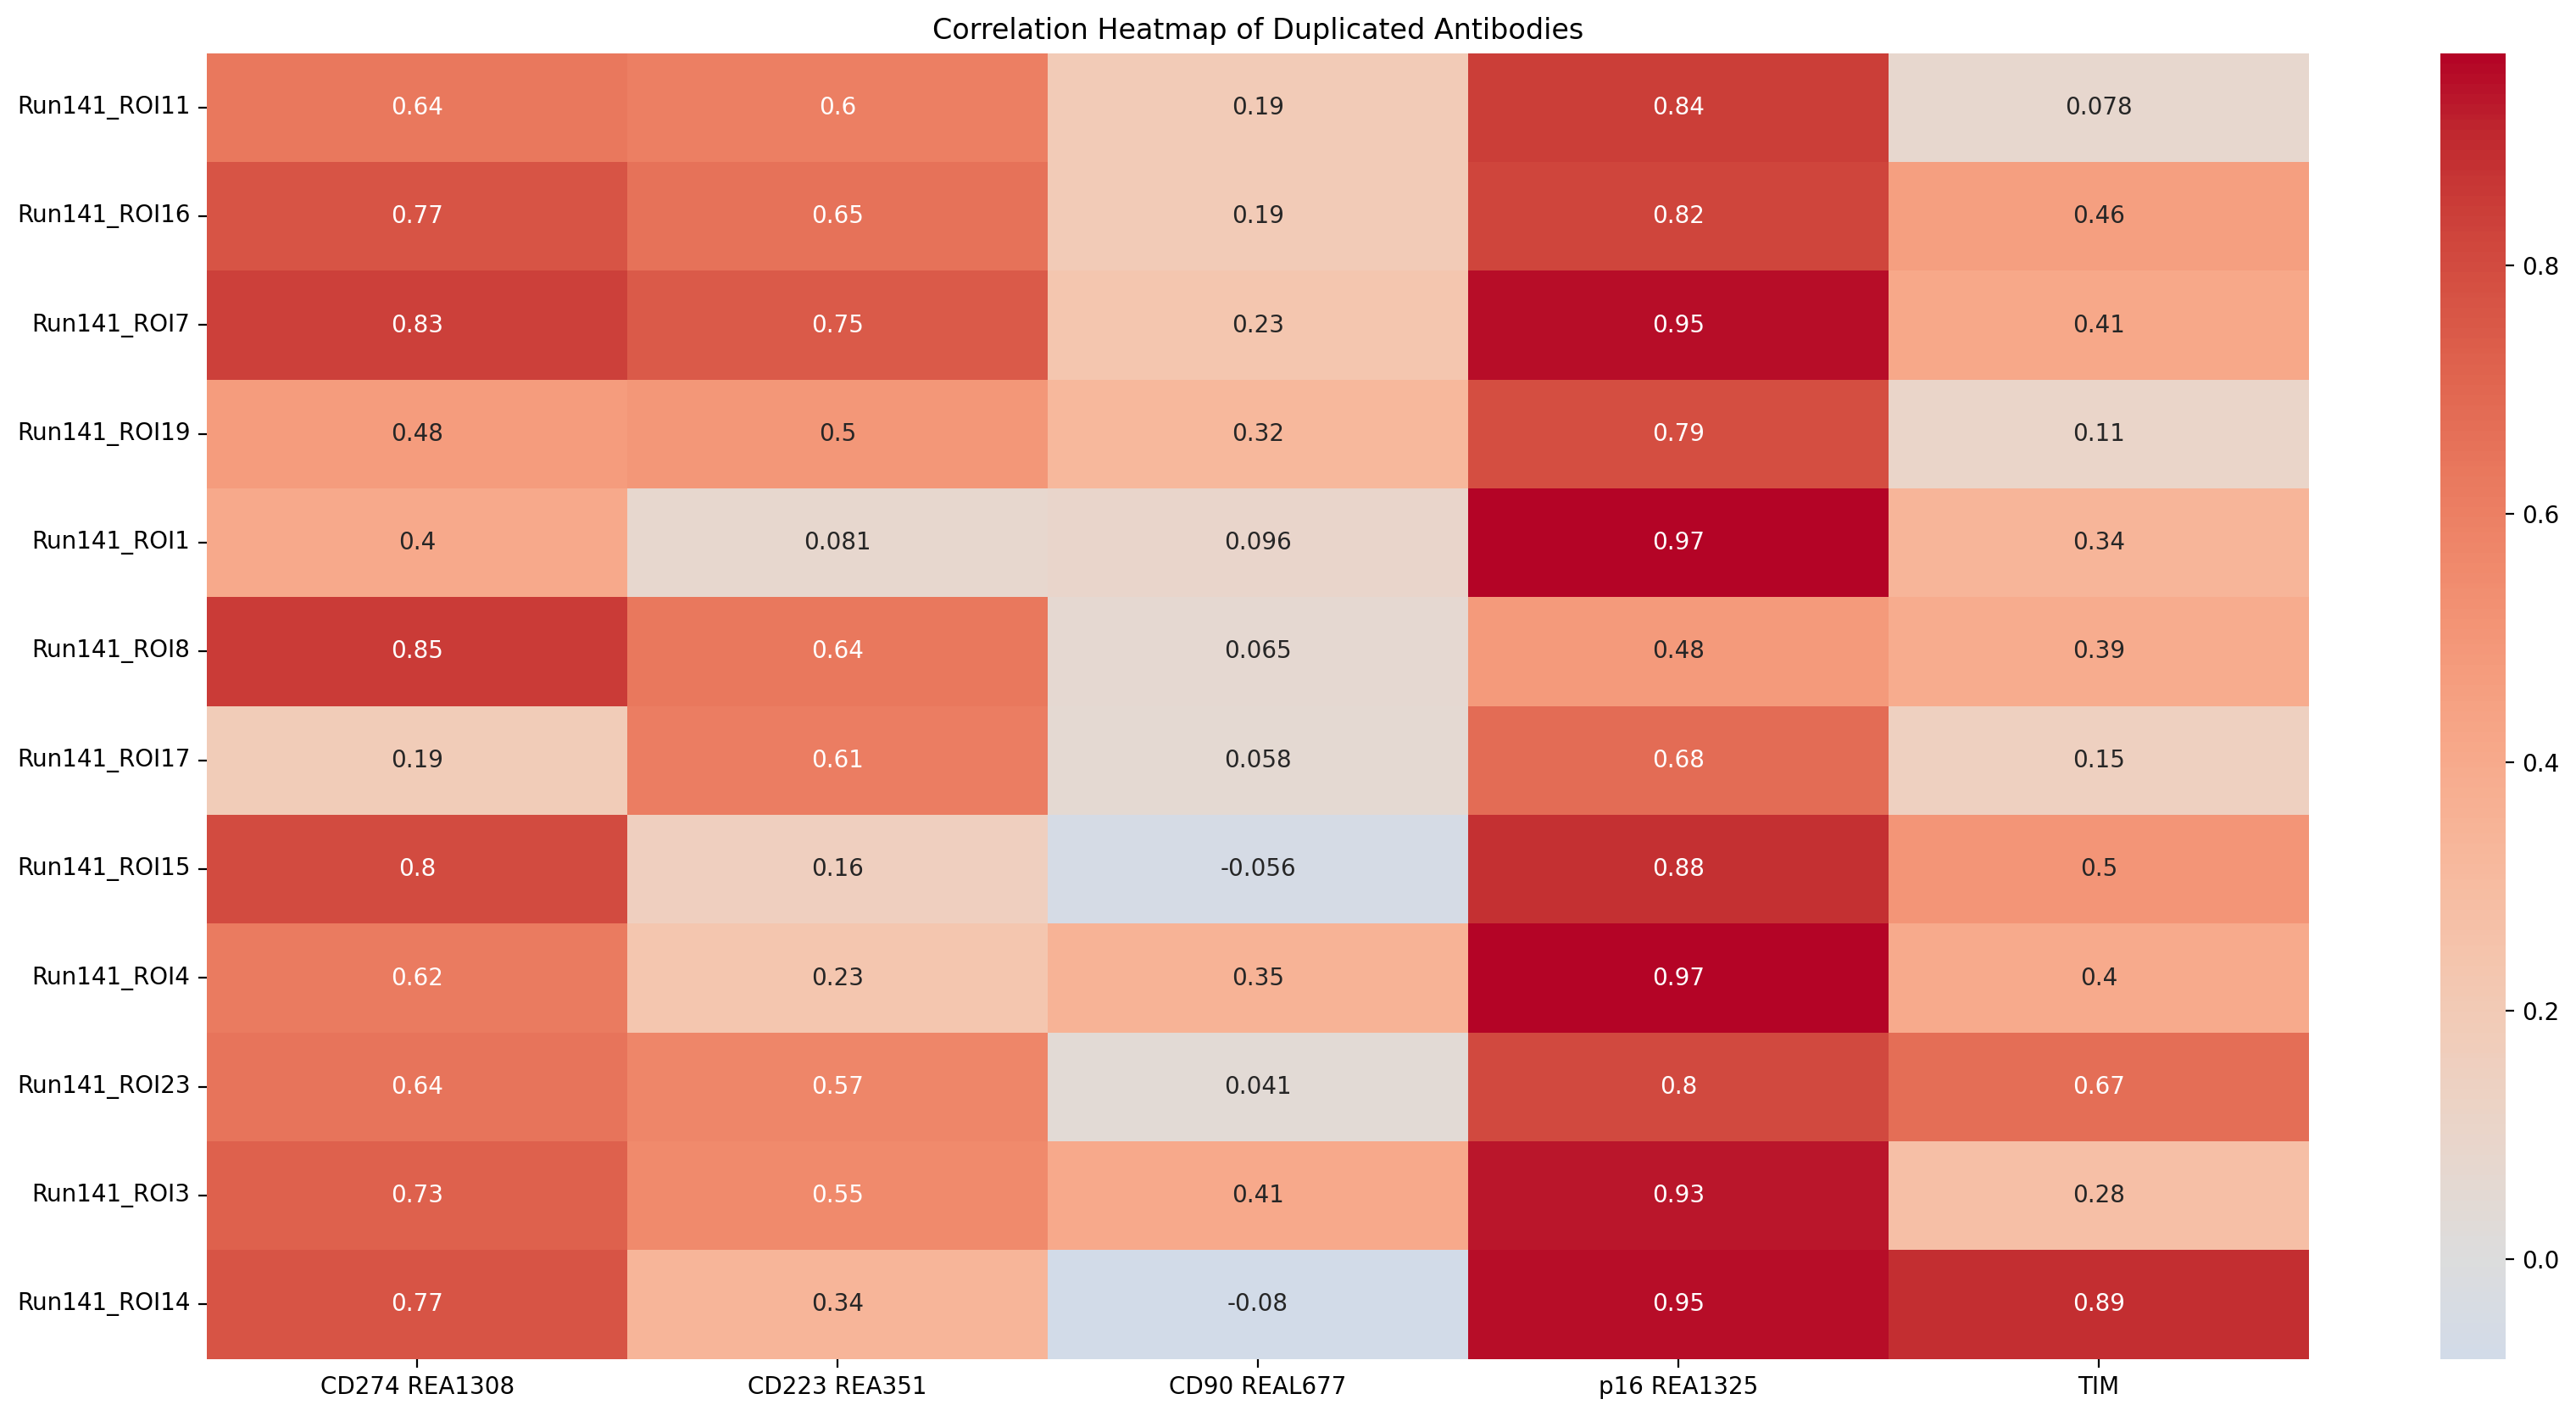

In [111]:
#Build the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Duplicated Antibodies")
plt.show()

## Averaging the duplicates

In [136]:
#let's average the expression of the duplicated antibodies
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    for marker in duplicated_antibodies:
        exp_filter = exp.filter(like = marker)
        exp = exp.loc[:, ~exp.columns.str.contains(marker)]
        exp[marker] = exp_filter.mean(axis=1)
    exp.rename(columns={"TIM": "TIM-3 REAL818"}, inplace=True)
    exp.to_csv(roi / 'exp.csv', index=False)